# IV inversion: Newton-Raphson + Brent vs bisection

Rebuilds the parity-blended unified call price from
`eda_quarterly_unified_iv_bisection.ipynb`, then solves for IV two ways: the
existing bisection baseline and a Newton-Raphson solver with a Brent fallback.
Both run on the same four quarterly `max_*` files, so speed and accuracy are
compared on identical inputs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import time

DATA_DIR = Path("../data")

FILES = {
    "Q1 (2023-01-04)": DATA_DIR / "Q1" / "max_spx_options_filtered_2023-01-04.csv",
    "Q2 (2023-06-30)": DATA_DIR / "Q2" / "max_spx_options_filtered_2023-06-30.csv",
    "Q3 (2023-08-15)": DATA_DIR / "Q3" / "max_spx_options_filtered_2023-08-15.csv",
    "Q4 (2023-11-14)": DATA_DIR / "Q4" / "max_spx_options_filtered_2023-11-14.csv",
}

frames = []
for label, path in FILES.items():
    df = pd.read_csv(path)
    df["quarter"] = label
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data["moneyness"] = data["strike"] / data["underlying_last"]
data.groupby("quarter").size()

quarter
Q1 (2023-01-04)    10442
Q2 (2023-06-30)    11979
Q3 (2023-08-15)    11591
Q4 (2023-11-14)    10308
dtype: int64

## Pair calls and puts, compute the unified price

Same pipeline as the bisection notebook: pair each call with its put on
`(quarter, strike, expire_date)`, build the parity-implied call price from the
put, and average it with the call mid.

$$
C_{unified} = \frac{C_{mid} + \left(P_{mid} + S e^{-qT} - K e^{-rT}\right)}{2}
$$

In [2]:
risk_free_rate = 0.05
dividend_yield = 0.00

calls = data[data["option_type"] == "call"]
puts = data[data["option_type"] == "put"]

pairs = calls.merge(
    puts,
    on=["quarter", "strike", "expire_date", "underlying_last", "dte"],
    suffixes=("_call", "_put"),
)

pairs["call_mid"] = (pairs["bid_call"] + pairs["ask_call"]) / 2
pairs["put_mid"] = (pairs["bid_put"] + pairs["ask_put"]) / 2
pairs["time_to_expiry"] = pairs["dte"] / 365

pairs["parity_call_mid"] = (
    pairs["put_mid"]
    + pairs["underlying_last"] * np.exp(-dividend_yield * pairs["time_to_expiry"])
    - pairs["strike"] * np.exp(-risk_free_rate * pairs["time_to_expiry"])
)
pairs["unified_call_price"] = (pairs["call_mid"] + pairs["parity_call_mid"]) / 2
pairs["moneyness"] = pairs["strike"] / pairs["underlying_last"]

pairs[["call_mid", "put_mid", "parity_call_mid", "unified_call_price"]].describe()

,call_mid,put_mid,parity_call_mid,unified_call_price
count,17966.000000,17966.000000,17966.000000,17966.000000
mean,471.529182,57.601770,482.065354,476.797268
std,496.325497,73.598161,500.231273,498.242644
min,0.075000,0.075000,1.257354,0.791177
25%,120.100000,7.950000,126.759655,123.614467
50%,295.375000,29.100000,305.936864,300.547838
75%,661.462500,78.950000,675.229654,667.874013
max,3452.450000,606.850000,3473.411258,3462.930629


## Baseline: Black-Scholes pricer and bisection solver

Copied from the bisection notebook. The no-arbitrage bound check is factored
into `_price_bounds_valid` so the Newton solver below shares it. Bisection halves
the bracket $[10^{-6}, 1.0]$ each step, so it gains one bit of precision per
Black-Scholes evaluation.

In [3]:
def black_scholes_call(spot, strike, time_to_expiry, volatility, rate, dividend):
    """Return the Black-Scholes European call price."""
    if time_to_expiry <= 0:
        return max(spot - strike, 0.0)

    volatility_sqrt_time = volatility * np.sqrt(time_to_expiry)
    d1 = (
        np.log(spot / strike)
        + (rate - dividend + 0.5 * volatility ** 2) * time_to_expiry
    ) / volatility_sqrt_time
    d2 = d1 - volatility_sqrt_time

    return (
        spot * np.exp(-dividend * time_to_expiry) * norm.cdf(d1)
        - strike * np.exp(-rate * time_to_expiry) * norm.cdf(d2)
    )


def _price_bounds_valid(target_price, spot, strike, time_to_expiry, rate, dividend, tolerance):
    """Shared no-arbitrage pre-check used by every solver below."""
    if any(pd.isna(v) for v in (target_price, spot, strike, time_to_expiry)) or time_to_expiry <= 0:
        return False
    discounted_spot = spot * np.exp(-dividend * time_to_expiry)
    discounted_strike = strike * np.exp(-rate * time_to_expiry)
    lower_bound = max(discounted_spot - discounted_strike, 0.0)
    upper_bound = discounted_spot
    return (target_price >= lower_bound - tolerance) and (target_price <= upper_bound + tolerance)


def implied_volatility_bisection(
    target_price,
    spot,
    strike,
    time_to_expiry,
    rate,
    dividend,
    lower_volatility=1e-6,
    upper_volatility=1.0,
    tolerance=1e-6,
    max_iterations=100,
):
    """Solve for call IV with bisection; return NaN if no valid bracket exists.

    Returns ``(iv, iterations)``.
    """
    if not _price_bounds_valid(target_price, spot, strike, time_to_expiry, rate, dividend, tolerance):
        return np.nan, 0

    low = lower_volatility
    high = upper_volatility
    low_price = black_scholes_call(spot, strike, time_to_expiry, low, rate, dividend)
    high_price = black_scholes_call(spot, strike, time_to_expiry, high, rate, dividend)

    if target_price < low_price - tolerance or target_price > high_price + tolerance:
        return np.nan, 0

    for iteration in range(1, max_iterations + 1):
        midpoint = (low + high) / 2
        midpoint_price = black_scholes_call(spot, strike, time_to_expiry, midpoint, rate, dividend)
        price_error = midpoint_price - target_price

        if abs(price_error) < tolerance:
            return midpoint, iteration
        if price_error < 0:
            low = midpoint
        else:
            high = midpoint

    return (low + high) / 2, max_iterations

## Newton-Raphson with a Brent fallback

**Newton-Raphson.** Vega is the derivative of the call price with respect to
volatility, so Newton can step straight toward the root instead of halving a
bracket.

$$
\sigma_{n+1} = \sigma_n - \frac{C_{BS}(\sigma_n) - C_{unified}}{\mathcal{V}(\sigma_n)},
\qquad \mathcal{V}(\sigma) = S e^{-qT} \varphi(d_1) \sqrt{T}
$$

Near the root the error roughly squares each step (quadratic convergence), so a
reasonable start like $\sigma_0 = 0.2$ usually converges in a handful of
iterations, where bisection needs about 20 or more.

**Where Newton fails.** Deep in- or out-of-the-money, vega is close to zero, so
the step divides by almost nothing and shoots off. Even with healthy vega, a
step can overshoot below zero or above any plausible volatility. The solver
stops Newton on either condition instead of taking the bad step.

**Brent fallback.** Brent's method combines bisection with secant and inverse
quadratic interpolation. It needs no derivative and is guaranteed to converge
whenever the bracket $[10^{-6}, 1.0]$ contains a sign change, so it catches
exactly the cases Newton cannot handle.

**Pros.** Guaranteed convergence given a bracket with a sign change, with no risk of the divide-by-near-zero-vega or out-of-bounds failures that force Newton to bail out. It also converges faster than plain bisection in practice, since the interpolation steps skip ahead when they're trustworthy and only fall back to bisection when they're not.

**Cons.** It needs that bracket up front, so it cannot start from a single guess the way Newton can. It also costs more per call than a converged Newton step, which is why it is used only as a fallback here (see the iteration counts later in this notebook) rather than as the primary solver for every row.

In [4]:
def black_scholes_vega(spot, strike, time_to_expiry, volatility, rate, dividend):
    """Return the Black-Scholes vega (call price sensitivity to volatility)."""
    d1 = (
        np.log(spot / strike)
        + (rate - dividend + 0.5 * volatility ** 2) * time_to_expiry
    ) / (volatility * np.sqrt(time_to_expiry))
    return spot * np.exp(-dividend * time_to_expiry) * norm.pdf(d1) * np.sqrt(time_to_expiry)


def implied_volatility_newton_brent(
    target_price,
    spot,
    strike,
    time_to_expiry,
    rate,
    dividend,
    lower_volatility=1e-6,
    upper_volatility=1.0,
    tolerance=1e-6,
    max_iterations=50,
    initial_guess=0.2,
):
    """Solve for call IV with Newton-Raphson, falling back to Brent.

    Returns ``(iv, used_fallback, iterations)``; ``iv`` is NaN when no valid
    bracket exists. ``iterations`` is Newton's own loop count, plus Brent's
    internal iteration count on fallback, so it reflects total solver work.
    """
    if not _price_bounds_valid(target_price, spot, strike, time_to_expiry, rate, dividend, tolerance):
        return np.nan, False, 0

    volatility = initial_guess
    newton_iterations = 0
    for _ in range(max_iterations):
        newton_iterations += 1
        price_error = black_scholes_call(spot, strike, time_to_expiry, volatility, rate, dividend) - target_price
        if abs(price_error) < tolerance:
            return volatility, False, newton_iterations

        vega = black_scholes_vega(spot, strike, time_to_expiry, volatility, rate, dividend)
        # Near-zero vega means the Newton step is dominated by rounding noise.
        if vega < 1e-10:
            break
        next_volatility = volatility - price_error / vega
        # Stepping outside the bracket would evaluate Black-Scholes at an invalid or meaningless vol.
        if not lower_volatility < next_volatility < upper_volatility:
            break
        volatility = next_volatility

    try:
        result, info = brentq(
            lambda vol: black_scholes_call(spot, strike, time_to_expiry, vol, rate, dividend) - target_price,
            lower_volatility,
            upper_volatility,
            xtol=tolerance,
            full_output=True,
        )
    except ValueError:
        return np.nan, True, newton_iterations
    return result, True, newton_iterations + info.iterations

## Solve with both, timed

Each solver runs once over every pair in all four quarters. The timer wraps the
full `.apply` call, so the numbers include pandas row overhead equally for both.

In [5]:
solver_args = lambda row: dict(
    target_price=row["unified_call_price"],
    spot=row["underlying_last"],
    strike=row["strike"],
    time_to_expiry=row["time_to_expiry"],
    rate=risk_free_rate,
    dividend=dividend_yield,
)

start = time.perf_counter()
pairs[["unified_iv", "bisection_iterations"]] = pairs.apply(
    lambda row: pd.Series(implied_volatility_bisection(**solver_args(row))), axis=1
)
bisection_seconds = time.perf_counter() - start

start = time.perf_counter()
pairs[["newton_brent_iv", "used_brent_fallback", "newton_iterations"]] = pairs.apply(
    lambda row: pd.Series(implied_volatility_newton_brent(**solver_args(row))), axis=1
)
newton_brent_seconds = time.perf_counter() - start
pairs["used_brent_fallback"] = pairs["used_brent_fallback"].astype(bool)

print(f"Rows processed: {len(pairs):,}")
print(f"Bisection:        {bisection_seconds:.3f} s")
print(f"Newton + Brent:   {newton_brent_seconds:.3f} s")
print(f"Speedup:          {bisection_seconds / newton_brent_seconds:.2f}x")

Rows processed: 17,966
Bisection:        12.606 s
Newton + Brent:   3.222 s
Speedup:          3.91x


## Cap solved IV at 100%

`src/filter_options.py` already caps the vendor's own IV column at 100%, justified by SPX's 2008 crisis peak of roughly 87% — the highest realized level in the index's history. Both solvers now search within `[1e-6, 1.0]` directly, so no row can solve above 100% in the first place — a row whose true root sits above the cap returns NaN instead. This check is kept as a regression guard: it should always report zero rows, and would only find something if the bracket were loosened again.

In [6]:
iv_cap = 1.0
exceeds_cap = (pairs["unified_iv"] > iv_cap) | (pairs["newton_brent_iv"] > iv_cap)
print(f"Dropping {exceeds_cap.sum()} row(s) with solved IV above {iv_cap:.0%}")
pairs = pairs.loc[~exceeds_cap].reset_index(drop=True)

Dropping 0 row(s) with solved IV above 100%


## Accuracy: Newton + Brent vs bisection

Both solvers stop at a $10^{-6}$ tolerance, so their IVs should agree to
roughly that level wherever both return a value. Rows where only one solver
returns `NaN` would point to a disagreement in bracket handling.

In [7]:
pairs["iv_diff"] = pairs["newton_brent_iv"] - pairs["unified_iv"]
both_valid = pairs["unified_iv"].notna() & pairs["newton_brent_iv"].notna()
nan_mismatch = pairs["unified_iv"].isna() != pairs["newton_brent_iv"].isna()

abs_diff = pairs.loc[both_valid, "iv_diff"].abs()
print(f"Rows with both IVs valid: {both_valid.sum():,} / {len(pairs):,}")
print(f"Rows where only one solver returned NaN: {nan_mismatch.sum():,}")
print(f"Mean |iv_diff|: {abs_diff.mean():.3e}")
print(f"Max  |iv_diff|: {abs_diff.max():.3e}")
pairs["iv_diff"].describe()

Rows with both IVs valid: 16,717 / 17,966
Rows where only one solver returned NaN: 0
Mean |iv_diff|: 1.316e-08
Max  |iv_diff|: 4.066e-05


count    1.671700e+04
mean     3.112136e-09
std      3.346819e-07
min     -8.443417e-06
25%     -9.530846e-10
50%      1.407417e-10
75%      1.459185e-09
max      4.065738e-05
Name: iv_diff, dtype: float64

In [8]:
pairs.groupby("quarter")["iv_diff"].describe()

,count,mean,std,min,25%,50%,75%,max
quarter,,,,,,,,
Q1 (2023-01-04),4099.0,1.846749e-10,8.886909e-09,-2.136411e-07,-8.490051e-10,8.426251e-11,1.165385e-09,1.639522e-07
Q2 (2023-06-30),4729.0,8.162373e-09,6.254809e-07,-8.443417e-06,-1.164819e-09,1.903813e-10,2.060606e-09,4.065738e-05
Q3 (2023-08-15),4720.0,2.458062e-09,6.838989e-08,-8.234808e-07,-1.068097e-09,1.592295e-10,1.671697e-09,3.102084e-06
Q4 (2023-11-14),3169.0,3.365980e-10,5.518003e-09,-8.640658e-08,-7.717251e-10,1.125014e-10,1.121021e-09,2.280993e-07


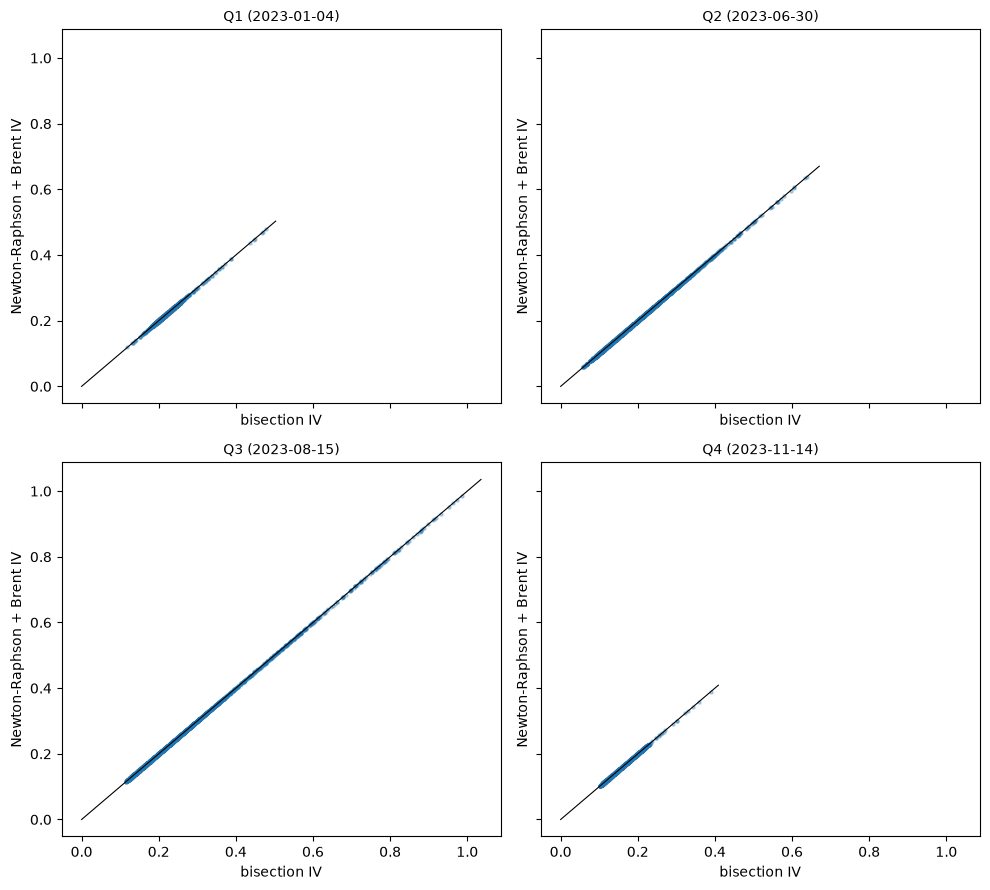

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
for ax, label in zip(axes.flat, FILES):
    subset = pairs[pairs["quarter"] == label]
    ax.scatter(subset["unified_iv"], subset["newton_brent_iv"], s=5, alpha=0.3)
    lims = [0, subset[["unified_iv", "newton_brent_iv"]].max().max() * 1.05]
    ax.plot(lims, lims, color="black", linewidth=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("bisection IV")
    ax.set_ylabel("Newton-Raphson + Brent IV")
fig.tight_layout()

In [ ]:
q3_label = "Q3 (2023-08-15)"
subset = pairs[pairs["quarter"] == q3_label]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(subset["unified_iv"], subset["newton_brent_iv"], s=5, alpha=0.3)
lims = [0, subset[["unified_iv", "newton_brent_iv"]].max().max() * 1.05]
ax.plot(lims, lims, color="black", linewidth=0.8)
ax.set_title(q3_label, fontsize=10)
ax.set_xlabel("bisection IV")
ax.set_ylabel("Newton-Raphson + Brent IV")
fig.tight_layout()

## Brent fallback rate by quarter

The share of rows where Newton bailed out and Brent produced the answer. A high
rate erodes the speedup, since those rows pay for the Newton attempt and a full
Brent solve.

quarter
Q1 (2023-01-04)      0.4%
Q2 (2023-06-30)     5.44%
Q3 (2023-08-15)    13.29%
Q4 (2023-11-14)     0.16%
Name: used_brent_fallback, dtype: str


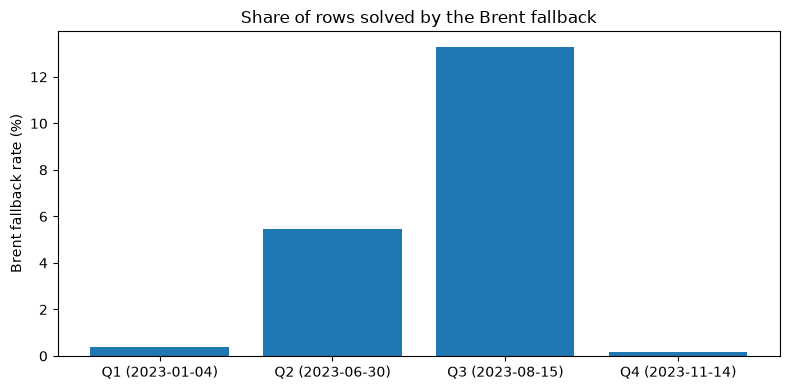

In [10]:
fallback_rate = pairs.groupby("quarter")["used_brent_fallback"].mean() * 100
print(fallback_rate.round(2).astype(str) + "%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(fallback_rate.index, fallback_rate.values)
ax.set_ylabel("Brent fallback rate (%)")
ax.set_title("Share of rows solved by the Brent fallback")
fig.tight_layout()

## Why Newton is faster: iterations per row

Bisection halves a fixed `[1e-6, 1.0]` bracket until the price is within tolerance, so it needs roughly the same number of steps regardless of where the root sits. Newton steps directly toward the root using vega, so it usually needs far fewer iterations — each one costing an extra vega evaluation, but still far cheaper overall. Rows that fall back to Brent add that solver's own iterations on top of the Newton attempt that preceded it.

In [11]:
both_valid = pairs["unified_iv"].notna() & pairs["newton_brent_iv"].notna()
iteration_stats = pairs.loc[both_valid, ["bisection_iterations", "newton_iterations"]].describe()
iteration_stats

,bisection_iterations,newton_iterations
count,16717.000000,16717.000000
mean,25.986959,4.800742
std,2.334408,2.215902
min,10.000000,2.000000
25%,25.000000,4.000000
50%,26.000000,4.000000
75%,28.000000,5.000000
max,30.000000,16.000000


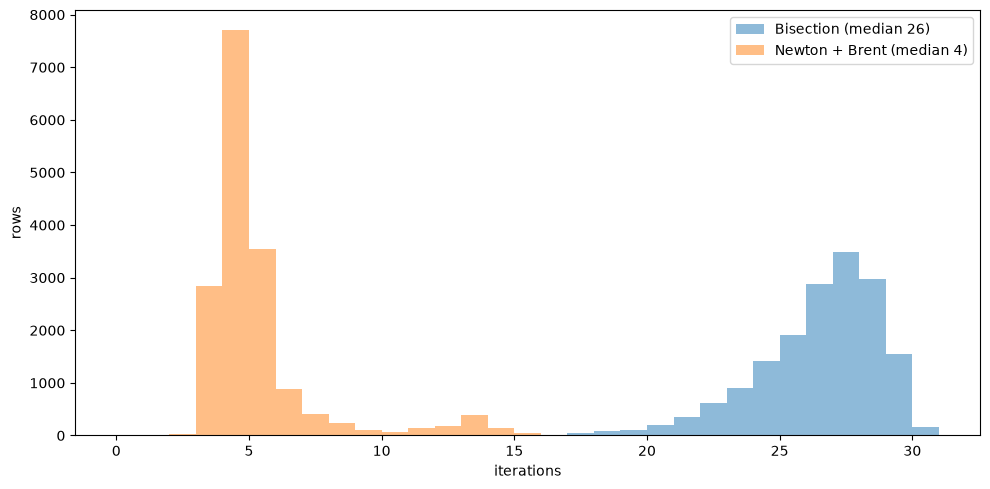

In [12]:
bisection_counts = pairs.loc[both_valid, "bisection_iterations"]
newton_counts = pairs.loc[both_valid, "newton_iterations"]
shared_bins = range(0, int(max(bisection_counts.max(), newton_counts.max())) + 2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bisection_counts, bins=shared_bins, alpha=0.5, color="tab:blue",
        label=f"Bisection (median {bisection_counts.median():.0f})")
ax.hist(newton_counts, bins=shared_bins, alpha=0.5, color="tab:orange",
        label=f"Newton + Brent (median {newton_counts.median():.0f})")
ax.set_xlabel("iterations")
ax.set_ylabel("rows")
ax.legend()
fig.tight_layout()